In [1]:
!pip install ultralytics opencv-python-headless matplotlib seaborn pandas torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.3/949.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
import torch
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Ensure Colab is using T4 GPU
gpu_info = !nvidia-smi --query-gpu=name --format=csv,noheader
if 'T4' not in gpu_info[0]:
    print("Warning: You are not using a T4 GPU. Consider switching runtime type.")

Using device: cuda


In [4]:
# Mount Google Drive (if dataset is stored there)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# Set dataset path (update this based on your dataset location)
dataset_path = '/content/drive/MyDrive/Colab Notebooks/Dataset'

In [6]:
# Define paths for train, validation, and test sets
image_dirs = {
    "train": os.path.join(dataset_path, 'images', 'train'),
    "valid": os.path.join(dataset_path, 'images', 'val'),
    "test": os.path.join(dataset_path, 'images', 'test')
}
label_dirs = {
    "train": os.path.join(dataset_path, 'labels', 'train'),
    "valid": os.path.join(dataset_path, 'labels', 'val'),
    "test": os.path.join(dataset_path, 'labels', 'test')
}


In [7]:
# Count images and annotations
for split in ["train", "valid", "test"]:
    num_images = len(os.listdir(image_dirs[split]))
    num_annotations = len(os.listdir(label_dirs[split]))
    print(f'{split.capitalize()} - Images: {num_images}, Annotations: {num_annotations}')


Train - Images: 1984, Annotations: 1984
Valid - Images: 189, Annotations: 189
Test - Images: 95, Annotations: 95


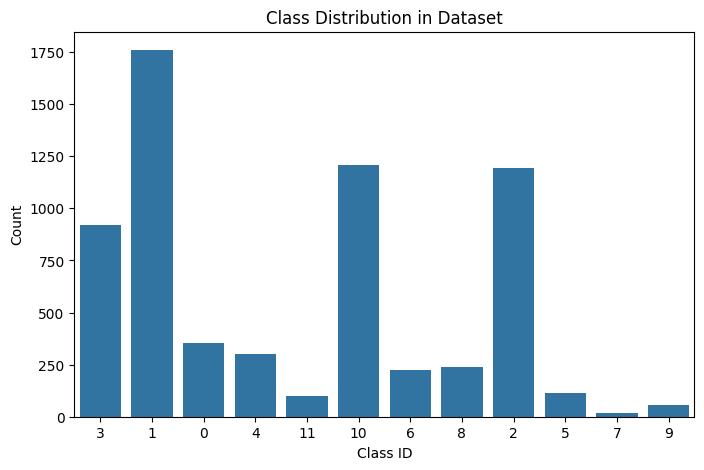

In [8]:
# Visualize class distribution
label_counts = {}
for split in label_dirs:
    for label_file in os.listdir(label_dirs[split]):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_dirs[split], label_file), 'r') as f:
                for line in f:
                    class_id = line.split()[0]
                    label_counts[class_id] = label_counts.get(class_id, 0) + 1

# Convert to DataFrame for visualization
label_df = pd.DataFrame(list(label_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(8, 5))
sns.barplot(x='Class', y='Count', data=label_df)
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.title('Class Distribution in Dataset')
plt.show()



Visualizing random images with correct class names...


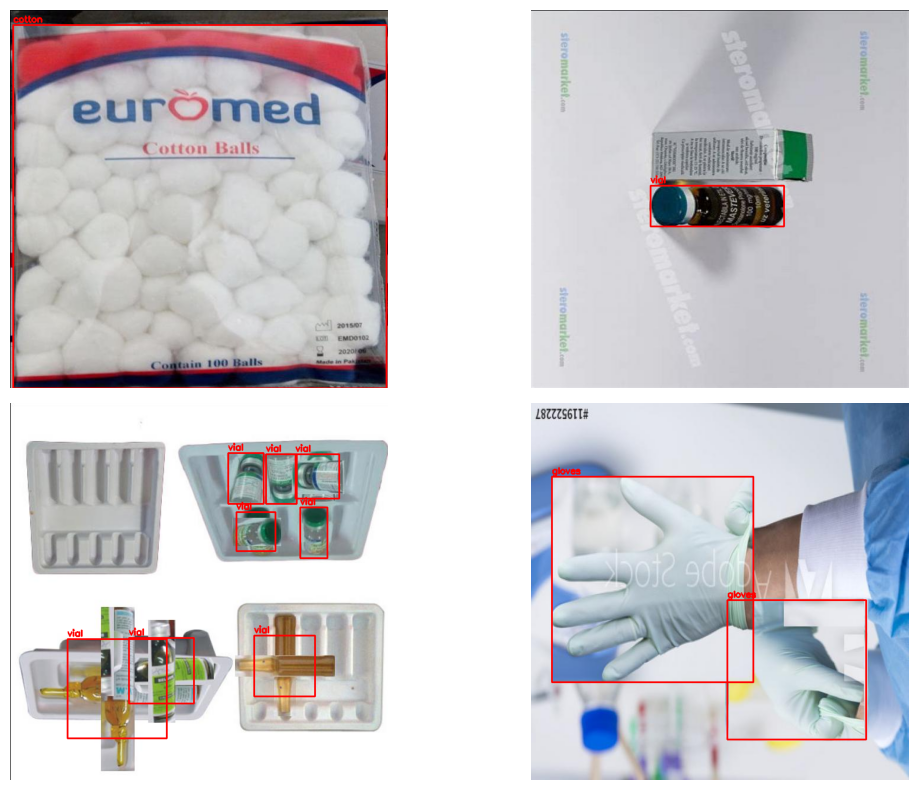

In [9]:
import yaml

# Load class names from YAML
yaml_path = os.path.join(dataset_path, "data.yaml")
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]  # Class names list

# Function to visualize images with bounding boxes and actual class names
def plot_images_with_bboxes(image_dir, label_dir, num_samples=4):
    image_files = random.sample(os.listdir(image_dir), num_samples)
    plt.figure(figsize=(12, 8))

    for i, image_file in enumerate(image_files):
        img_path = os.path.join(image_dir, image_file)
        label_path = os.path.join(label_dir, image_file.replace('.jpg', '.txt'))

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    values = line.split()
                    if len(values) < 5:
                        continue

                    class_id, x_center, y_center, bbox_width, bbox_height = map(float, values[:5])
                    class_id = int(class_id)
                    class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"

                    # Convert YOLO bbox format to pixel coordinates
                    x1 = int((x_center - bbox_width / 2) * w)
                    y1 = int((y_center - bbox_height / 2) * h)
                    x2 = int((x_center + bbox_width / 2) * w)
                    y2 = int((y_center + bbox_height / 2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, class_name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize images with class names instead of IDs
print("Visualizing random images with correct class names...")
plot_images_with_bboxes(image_dirs["train"], label_dirs["train"])


In [10]:
# Load YOLOv8 model
model = YOLO('yolov8s.pt')  # Use 'yolov8n.pt' for a smaller model


100%|██████████| 21.5M/21.5M [00:00<00:00, 411MB/s]


In [12]:
model.train(
    data=f"{dataset_path}/data.yaml",  # Path to the dataset YAML file
    epochs=100,  # Adjust based on your needs
    batch=16,
    imgsz=640,
    device=device,
    workers=2,
    name='yolov8_medical_waste'
)

Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/Colab Notebooks/Dataset/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=2, project=None, name=yolov8_medical_waste2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fals

100%|██████████| 5.35M/5.35M [00:00<00:00, 238MB/s]


AMP: checks passed ✅


train: Scanning /content/drive/MyDrive/Colab Notebooks/Dataset/labels/train.cache... 1984 images, 49 backgrounds, 0 corrupt: 100%|██████████| 1984/1984 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

                   all        189        519      0.892      0.526      0.626      0.474



100 epochs completed in 1.711 hours.
Optimizer stripped from runs/detect/yolov8_medical_waste2/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/yolov8_medical_waste2/weights/best.pt, 22.5MB

Validating runs/detect/yolov8_medical_waste2/weights/best.pt...
Ultralytics 8.3.93 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:06<00:00,  1.16s/it]


                   all        189        519      0.828      0.577      0.629      0.474
                IVtube         23         26      0.744      0.671      0.705      0.511
               bandage         31        112      0.867      0.893      0.937      0.832
                cotton         27        117      0.722      0.504      0.609       0.42
                gloves         49         96      0.824      0.681      0.745      0.569
                  mask         23         30      0.917      0.733        0.8      0.575
           medical cap          7          9      0.746      0.889      0.892      0.744
                needle         10         10          1      0.688      0.809      0.486
              scissors          1          2          1          0          0          0
               syringe         19         19      0.865      0.675      0.765      0.495
             test tube          1          1          1          0          0          0
                  via

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a38daba6650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [16]:
model_path = "/content/runs/detect/yolov8_medical_waste2/weights/best.pt"  # Update this
model = YOLO(model_path)

# Set the image path (Update this path)
image_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/images/test/hand_throwing_away_blue_disposable_gloves_medical_isolated_on_white_JJXKMT_jpg.rf.9c479573fd4709fe95879fa9be79a369.jpg"  # Update this

# Run inference on the image
results = model(image_path)

# Extract and display the processed image directly in Colab using Matplotlib
im_array = results[0].plot()[:, :, ::-1]  # Convert BGR to RGB

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(im_array)
plt.axis("off")  # Hide axes
plt.show()


image 1/1 /content/drive/MyDrive/Colab Notebooks/Dataset/images/test/hand_throwing_away_blue_disposable_gloves_medical_isolated_on_white_JJXKMT_jpg.rf.9c479573fd4709fe95879fa9be79a369.jpg: 640x640 3 glovess, 16.4ms
Speed: 2.3ms preprocess, 16.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


NameError: name 'cv2_imshow' is not defined